# INF8460 – Traitement automatique de la langue naturelle - Automne 2025

# TP 2 : BERT pour la reconnaissance d'entités nommées (NER) (100 pts)

## Identification de l'équipe:

### Groupe de laboratoire: GR1

### Equipe numéro : E13

### Membres:

- Clara Kowalczyk (33% de contribution)
- Quentin Touil (33% de contribution)
- Omar Benzekri (33% de contribution)

Nature de la contribution:

- Partie 1 : Clara et Quentin
- Partie 2 : Clara et Quentin
- Partie 3.1 : Clara et Quentin
- Partie 3.2 : Clara et Quentin (3.2.1), Clara (3.2.2, 3.2.3 3.2.4), Omar (3.2.2, 3.2.5, 3.2.6, 3.2.7)
- Partie 3.3 : Omar
- Partie 3.4 : Omar
- Partie 4 : Omar

## Usage des LLMs

Notez que l'usage des LLMs est strictement prohibé.

Vous devez masquer les fonctionnalités d'IA générative dans les paramètres de Colab (Paramètres -> Assistance IA).

Même si cela demande plus d'effort et de temps, la résolution des TPs par vos propres moyens vous permettra d'acquérir toutes les compétences en TALN pour vos travaux futurs. Nous incluerons des questions de code des TPs dans l'examen final et considérerons toute utilisation de LLM comme un cas de plagiat.

## Description du TP  :
### BERT pour la reconnaissance d'entitée nommée - BIO tagging


Dans ce TP, vous allez créer l'architecture d'un modèle **BERT** puis l'entraîner sur la tâche de reconnaissance des entités nommées dans le domaine médical, plus spécifiquement sur la tâche d'identification d'effets secondaires de médicaments (*Adverse drug events*). Nous utiliserons ensuite une version pré-entraînée de BERT, et comparerons les performances de notre modèle entrainé à celles de BERT avec affinage.

La reconnaissance d'entités nommées, ou Named Entity Recognition (NER) est la tâche d'identification et de classification d'entités à partir de texte. Il peut s'agir par exemple de reconnaitre les noms de personnes, d'organisations ou de lieux. Dans notre cas précis, voici un exemple des données utilisées :

Phrase d'entrée : `"In one case, the readministration of riluzole was followed by the relapse of hepatitis."`

Sortie attendue (effet secondaire) : `"hepatitis"`

On définit comme **mentions** les différentes expressions qui désignent les entités nommées extraites (ici : "hepatitis"),  comme **étiquette** la classe associé à l'entité extraite (ici : *Adverse Drug Event* ou *ADE*), et comme **span** l'intervalle spécifié par les index dans la phrase correspondant aux mentions (ici : [13, 14] car "hepatitis" débute à l'index 13 et se termine à l'index 14).

Pour faire de la reconnaissance d'entité nommée avec BERT, nous allons adopter le format d'étiquettage BIO (*BIO tagging*), qui consiste à étiqueter chaque jeton comme appartenant aux classes B - Beginning, I - Inside ou O - Outside.

Par exemple, si la phrase à étiqueter est la suivante :

> Les fondateurs de Microsoft sont Bill Gates et Paul Allen

Et que nous cherchons à identifier toutes les mentions de personnes (P), nous utiliserions les étiquettes (B-P, I-P, O) de la manière suivante:

> Les`(O)` fondateurs`(O)` de`(O)` Microsoft`(O)` sont`(O)` Bill`(B-P)` Gates`(I-P)` et`(O)` Paul`(B-P)` Allen`(I-P)`

C'est ce qui constituera la sortie de nos modèles, les mentions (`Bill Gates`, `Paul Allen`) seront ensuite extraites automatiquement à partir des étiquettes BIO.

Dans le contexte du TP, la classe d'intérêt sera les effets secondaires négatifs (*Adverse Drug Events* - ADE). Ici, les jetons seront des sous-mots et non des mots complets comme dans l'exemple, mais le principe demeure le même.



Structure du TP :

- Données d'entrainement (prétraitement, split en train-test-val, etc.)
- Module d'évaluation
- Custom BERT
  - architecture
  - entrainement
- Alternative
  - BERT-base (pré-entrainé)
- Evaluation
- Questions d'analyse

**Prérequis et ressources utiles**

Avant de commencer, il est fortement recommandé d’avoir une bonne compréhension de la bibliothèque PyTorch. En particulier, vous devriez savoir :

ce qu’est une classe nn.Module, et
comment fonctionne la méthode forward.
Voici quelques ressources utiles pour vous aider à vous (re)familiariser avec les bases :

- [Build The Neural Network](https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html)
- [PyTorch Tutorial](https://github.com/yunjey/pytorch-tutorial?tab=readme-ov-file)


---
### Fichiers du TP

En plus du notebook Python, vous aurez le fichier:

* **effets_secondaires.csv** : jeu de données contenant les phrases et les mentions d'effets secondaires

---
## Préparation de l'environnement

In [1]:
#@title Imporation des bibliothèques

# librairies de base
import pandas as pd
import numpy as np
import math
from tqdm import tqdm
import re
from collections import defaultdict
import warnings
import os
import sys

# Pytorch
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

# Modèle pré-entrainé
from transformers import AutoTokenizer, BertForTokenClassification, AutoModelForTokenClassification

# graphiques
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from google.colab import drive

In [2]:
#@title Connection à Google Drive
drive.mount('/content/drive', force_remount=True)

folder = '/content/drive/MyDrive/INF8460/TP2/data/' # Changer le path vers le dossier TP2 dans votre Drive

# Ajoute le dossier au path Python
if folder not in sys.path:
  sys.path.insert(0, folder)

Mounted at /content/drive


In [3]:
#@title Définition du device
if not torch.cuda.is_available():
  warnings.warn('CUDA is not available.')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}")

device : cuda


---
## 1. Préparation des données et premières analyses (14 pts)

- Importation des données
- Familiarisation avec le jeu de données
- Prétraitement
- Création de la classe NERDataset
- Importation du Tokenizer
- Train-Test-Val split

### 1.1 Importation des données

In [4]:
df = pd.read_csv(folder + '/effets_secondaires.csv')

Familiarisez-vous avec le jeu de données en observant quelques exemples

In [5]:
df.head()

,Unnamed: 0,sentence,ade_span
0,0,a 33 - year - old male presented with brown di...,brown discolouration of the fingernails
1,1,here we describe a patient with crohn ' s dise...,severe swelling of the forearm and hand ipsila...
2,2,focal glomerulonephritis and interstitial neph...,interstitial nephritis
3,3,near fatal acute colchicine intoxication in a ...,colchicine intoxication
4,4,neurologic symptoms resolved after stopping ca...,neurologic symptoms


### 1.2 Familiarisation avec le jeu de données (8 pts)

Avant d’entraîner un modèle, il est essentiel de bien comprendre le contenu du corpus.

Dans cette section, vous allez réaliser une brève analyse statistique des données d'entrainement

**Q-1.2.1 (2 pts) Codez tout d'abord la fonction suivante prenant en entrée une ligne du DataFrame `df` contenant les données originales et retournant le premier index d'apparition de la mention dans la phrase**

Ex :

phrase : *Ceci est un exemple.*

mention : *exemple*

→ premier index : 3

In [6]:
#@title get_span_start_position
def get_span_start_position(row):
    """
    Retourne le premier index d'apparition de la mention dans la phrase

    Args:
        row (pandas.Series): Une ligne du DataFrame
            (sentence: la phrase, ade_span: mention correspondante)

    Returns:
        int: Index d'apparition de la mention dans la phrase
    """

    index = None

    ### TODO ###
    mention = row['ade_span']
    sentence = row['sentence'].split(mention)
    index = len(sentence[0].split())

    ### END TODO ###

    return index

**Q-1.2.2 (3 pts) Remplissez ensuite la fonction suivante calculant le nombre de mots moyen par phrase, la position moyenne des premiers spans dans les phrases (en utilisant `get_span_start_position`), et le nombre total de spans uniques. Affichez les résultats**

In [7]:
#@title describe_dataset
def describe_dataset(df):
    """
    Retourne la moyenne de mots par phrase, la position moyenne des mentions et
    le nombre de mentions uniques

    Args:
        df (pandas.DataFrame): Le DataFrame contenant les données

    Returns:
        dict: Un dictionnaire contenant les statistiques
    """
    # Nombre moyen de mots par phrase
    mean_words_per_sentence = None
    ### TODO ###
    df['word_count'] = df['sentence'].apply(lambda x: len(x.split()))
    mean_words_per_sentence = df['word_count'].mean()
    ### END TODO ###

    # Position moyenne des spans en nombre de mots
    mean_ade_start_position = None
    ### TODO ###
    df['ade_start_position'] = df.apply(get_span_start_position,axis=1)
    mean_ade_start_position = df['ade_start_position'].mean()
    ### END TODO ###

    # Nombre total de spans ADE uniques
    num_unique_ade_spans = None
    ### TODO ###
    num_unique_ade_spans = len(df['ade_span'].unique())
    ### END TODO ###

    return {
        "mean_words_per_sentence": mean_words_per_sentence.round(1),
        "mean_ade_start_position": mean_ade_start_position.round(1),
        "num_unique_ade_spans": num_unique_ade_spans
    }

print(describe_dataset(df))

{'mean_words_per_sentence': np.float64(25.1), 'mean_ade_start_position': np.float64(11.1), 'num_unique_ade_spans': 2983}


Valeurs attendues :


`{'mean_words_per_sentence': np.float64(25.1), 'mean_ade_start_position': np.float64(11.1), 'num_unique_ade_spans': 2983}`

**Q-1.2.3 (3 pts) Complétez la cellule suivante permettant de générer deux graphiques, le premier montrant la distribution du nombre de mots par phrase et le second montrant la distribution des index d'apparition des mentions (utilisant la fonction `get_span_start_position`).**

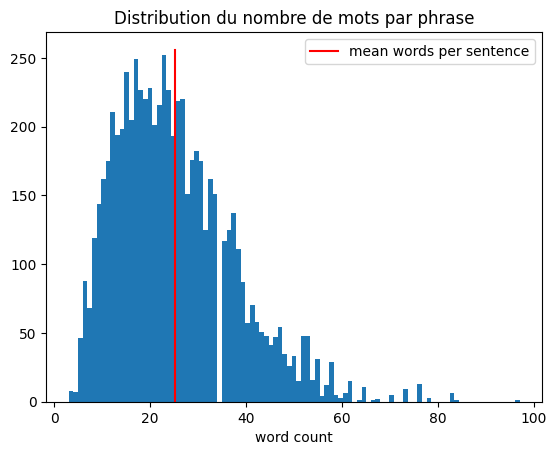

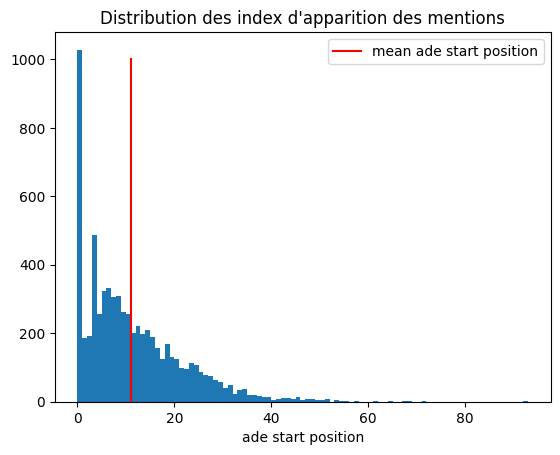

In [8]:
#@title Graphiques d'exploration des données
mean_words_per_sentence = df['word_count'].mean()
mean_ade_start_position = df['ade_start_position'].mean()
### TODO ###
plt.hist(df['word_count'],bins=df['word_count'].max())
plt.plot([mean_words_per_sentence,mean_words_per_sentence],[0,256],color='red',label='mean words per sentence')
plt.legend()
plt.title('Distribution du nombre de mots par phrase')
plt.xlabel('word count')
plt.show()

plt.figure()

plt.hist(df['ade_start_position'],bins=df['ade_start_position'].max())
plt.plot([mean_ade_start_position,mean_ade_start_position],[0,1000],color='red',label='mean ade start position')
plt.legend()
plt.title('Distribution des index d\'apparition des mentions')
plt.xlabel('ade start position')
plt.show()
### END TODO ###

### 1.3 Prétraitement (5 pts)

Les données brutes contiennent une ligne par mention d'effet secondaire.

Par exemple, les données originales pourraient contenir les trois lignes suivantes:

**Text** - **ade_span**

`The patient suffered confusion and nausea after administration of Tylenol` - `confusion`

`The patient suffered confusion and nausea after administration of Tylenol` - `nausea`

`They were admitted following severe abdominal pain after treatment` - `severe abdominal pain`

Nous allons donc prétraiter les données afin que les différentes mentions contenues dans une même phrase soient mise en commun. Pour ce faire, nous allons :

1- Regrouper les mentions d’effets secondaires (ade_span) par phrase (sentence).

2- Segmenter chaque phrase en mots (tokens).

3- Associer à chaque mot une étiquette au format BIO :

- O : le mot n’appartient pas à une mention d’effet secondaire.

- B-ADE : le mot est le premier mot d’une mention.

- I-ADE : le mot fait partie de la suite de la mention.

4- Retourner :

- une liste d’exemples, chaque exemple étant constitué des tokens de la phrase et des labels BIO associés,

- liste des phrases originales.

Par exemple, pour les trois lignes précédentes, les sorties attendues seraient:

```
examples = [(["The", "patient", "suffered", "confusion", "and", "nausea", "after", "administration", "of", "Tylenol"],
["O", "O", "O", "B-ADE", "O", "B-ADE", "O", "O", "O", "O"]),
 (["The", "patient", "developed", "severe", "abdominal", "pain", "and", "persistent", "vomiting", "after", "treatment"],
 ["O", "O", "O", "B-ADE", "I-ADE", "I-ADE", "O", "O", "O", "O", "O"])]

sentences = ["The patient suffered confusion and nausea after administration of Tylenol",
"They were admitted following severe abdominal pain after treatment"]
```



**Q-1.3.1 (5 pts) Codez la fonction suivante permettant de faire ces opérations :**

In [9]:
#@title Fonction de prétraitement + étiquettage
def preprocessing(df):
    """
    Prétraite un jeu de données de phrases contenant des mentions d'effets secondaires
    et génère des séquences de tokens associées à des étiquettes BIO.

    Étapes principales :
        - Regroupe les mentions d'effet secondaire par phrase.
        - Découpe chaque phrase en tokens (mots).
        - Associe à chaque mot une étiquette BIO :
            * "O" : mot hors mention d'effet secondaire.
            * "B-ADE" : début d'une mention d'effet secondaire.
            * "I-ADE" : suite d'une mention d'effet secondaire.
        - Retourne la liste des paires (tokens, labels) ainsi que les phrases originales.

    Args
    ----------
    df : pandas.DataFrame
        DataFrame contenant au minimum deux colonnes :
            - "sentence" : la phrase source.
            - "ade_span" : les mentions textuelles d'effets secondaires présentes dans la phrase.

    Returns
    --------
    examples : list of tuple
        Liste de couples (mots, étiquettes) où :
            - mots (list[str]) : liste des tokens d'une phrase.
            - étiquettes (list[str]) : liste des labels BIO associés aux tokens.
    sentences : list of str
        Liste des phrases originales correspondant aux exemples.
    """
    examples = []
    sentences = []

    # Groupe toutes les mentions d'effet secondaire par phrase
    grouped = df.groupby('sentence')['ade_span'].apply(lambda spans: list(filter(pd.notna, spans))).reset_index()
    grouped = grouped.sample(frac=1).reset_index(drop=True)

    # Identifie les mentions, les mots de la phrase et les labels BIO associés
    for _, row in grouped.iterrows():

        ### TODO ###
        sentence = row['sentence']
        ade_spans = row['ade_span']

        mots = sentence.split()
        etiquettes = ['O']*len(mots)

        for span in ade_spans :
          row_unique = row.copy()
          row_unique['ade_span'] = span
          index = get_span_start_position(row_unique)
          etiquettes[index] = 'B-ADE'
          for i in range(1,len(span.split())):
            etiquettes[index+i] = 'I-ADE'

        examples.append((mots,etiquettes))
        sentences.append(sentence)
        ### END TODO

    return examples, sentences

In [10]:
#@title Affichage d'un exemple de données prétraitées

examples, sentences = preprocessing(df)
# examples : liste contenant une liste des mots de la phrase et une liste des labels associés
# sentences : liste contenant les phrases

for i in range(5):
  print(' '.join(examples[i][0]))
  print(examples[i][1])

ritonavir acted as a cyp3a4 inhibitor , diminishing carbamazepine metabolism and provoking an increase in serum levels and clinical toxicity .
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ADE', 'I-ADE', 'I-ADE', 'O', 'O', 'O', 'B-ADE', 'I-ADE', 'I-ADE', 'I-ADE', 'O', 'B-ADE', 'I-ADE', 'O']
possible mechanisms by which clonidine decreases spasticity are described , probable mechanisms of induced bradycardia are reviewed , and specific treatment recommendations for the use of clonidine in spinal cord injured patients are presented .
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ADE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
colonic mucosal necrosis following administration of calcium polystryrene sulfonate ( kalimate ) in a uremic patient .
['B-ADE', 'I-ADE', 'I-ADE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
a 40 - year - old man with a long standing history of rheumatoid arthrit

### 1.4 NERDataset

Ensuite, nous allons créer une classe NERDataset héritant des Datasets de Pytorch afin de faciliter l'entrainement des modèles. Nous allons également définir une correspondance entre les étiquettes BIO (B-ADE, I-ADE et O) et les labels prédits par nos modèles ; 1, 2 et 0 respectivement

In [11]:
#@title Correspondance BIO - Labels
tags = ['O', 'B-ADE', 'I-ADE']
label2id = {l: i for i, l in enumerate(tags)}
id2label = {i: l for l, i in label2id.items()}

La classe NERDataset va hériter de Dataset de pytorch, voir la documentation [ici](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html), particulièrement la section `Creating a Custom Dataset for your files`.



In [12]:
#@title Classe NERDataset

class NERDataset(torch.utils.data.Dataset):
    def __init__(self, examples, tokenizer, label2id, max_len=128):
        self.examples = examples
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_len = max_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        tokens, labels = self.examples[idx]  # jetons = ['The', 'drug', ...], labels = ['O', 'O', ...]

        # Tokenize et aligne les labels
        encoding = self.tokenizer(tokens,
                                  is_split_into_words=True,
                                  padding='max_length',
                                  truncation=True,
                                  max_length=self.max_len,
                                  return_tensors='pt')

        labels_aligned = []
        last_word_id = None
        word_ids = encoding.word_ids(batch_index=0)

        for word_id in word_ids:
            if word_id is None:
                labels_aligned.append(-100)

            elif word_id != last_word_id:
                labels_aligned.append(self.label2id[labels[word_id]])

            else:
                # Subword token -> à ignorer dans le calcul de la loss
                labels_aligned.append(-100)
            last_word_id = word_id

        item = {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(labels_aligned)
        }
        return item

### 1.5 Tokenizer

La prochaine étape dans la création du Dataset final est le téléchargement du tokenizer utilisé par BERT pour transformer une phrase en jetons. BERT fait usage du Tokenizer [WordPiece](https://huggingface.co/learn/llm-course/en/chapter6/6), que nous pouvons télécharger directement à partir de `Huggingface`. Nous aurons besoin de ce tokenizer pour instancier différents NERDataset correspondants à l'entrainement, la validation et le test.

Le tokenizer est la partie du modèle qui décompose le texte en jetons, et chaque jeton est associé à un identifiant (token_ids) et a une représentation vectorielle (embedding).

In [13]:
#@title Tokenizer

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

### 1.6 Train-Test-Val Split (1 pts)

Il nous faut ensuite séparer le jeu de données en ensemble d'entrainement, de test et de validation, afin de pouvoir entrainer le modèle, choisir certains hyperparamètres sans introduire de biais et finalement évaluer la performance réelle de nos modèles.

**Q-1.6.1 (1 pts) Pour ce faire, complétez la cellule suivante qui mélange les données avec un seed prédéfini (42) puis sépare les exemples définis plus haut en trois (70% pour l'entrainement, 15% pour le test et la validation). Instanciez ensuite les trois NERDatasets.**

In [14]:
#@title Split

# split train/test/val (70/15/15)

# shuffle les données avec le seed 42
### TODO ###
np.random.seed(42)
np.random.shuffle(examples)
### END TODO ###


### TODO ###
splits = [int(len(examples)*0.7),int(len(examples)*0.85)]
train_examples, test_examples, val_examples = examples[0:splits[0]], examples[splits[0]:splits[1]], examples[splits[1]:]
### END TODO ###

#train/test/val_examples devraient être identiques à l'objet examples mais de taille adéquate (70/15/15)

train_dataset = NERDataset(train_examples, bert_tokenizer, label2id)
test_dataset  = NERDataset(test_examples, bert_tokenizer, label2id)
val_dataset   = NERDataset(val_examples, bert_tokenizer, label2id)

Nous allons ensuite utiliser ces NERDatasets à travers la classe DataLoader de Pytorch, encore une fois afin de faciliter l'entrainement. Nous définissons également ici la taille de batch utilisées pendant l'entrainement.

In [15]:
#@title Batch size d'entrainement
BATCH_SIZE = 64

Finalement, pour traiter les données efficacement et les répartir en batch durant l'entrainement, nous allons utiliser la classe [DataLoaders](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html) de Pytorch, qui permet de faire ces différentes opérations automatiquement (voir la section `Preparing your data for training with DataLoaders`).

In [16]:
#@title DataLoaders
train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=False,
                          collate_fn=lambda batch: {
                              'input_ids': torch.stack([item['input_ids'] for item in batch]),
                              'attention_mask': torch.stack([item['attention_mask'] for item in batch]),
                              'labels': torch.stack([item['labels'] for item in batch]),
                          })

val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=False,
                        collate_fn=train_loader.collate_fn)

test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False,
                         collate_fn=train_loader.collate_fn)

---
## 2. Module d'évaluation (9 pts)

### 2.1 Explications

Nous allons dès maintenant créer les fonctions permettant d'évaluer notre modèle sur la tâche de NER. Cela nous permettera d'évaluer nos modèles durant leur entrainement et ainsi suivre leur progression.

Considérant le format BIO que nous avons adopté, nous allons mesurer la performance de deux manières différentes:
- Au niveau des mentions : Nous allons comparer les mentions données à celles prédites par le modèle. Nous allons faire cette comparaison de deux façons différentes:
  - Matchs exacts : deux mentions seront évaluées comme étant équivalentes uniquement si elles sont identiques
  - Matchs approximatifs : la mention donnée par la modèle sera évaluée comme valide si il existe un chevauchement avec la mention 'gold' (ex: `'crise aigue' == 'crise'`)


- Au niveau des étiquettes : Nous allons comparer chaque étiquette individuellement (chaque étiquette BIO de chaque jeton sera comptée comme valide si elle est la même dans la sortie du modèle et dans les données)

Pour ces deux façons d'évaluer, nous utiliserons les mêmes métriques, c'est à dire la précision et le rappel, nous permettant ensuite de calculer le Score-F1:

### Précision

> **La précision** répond à la question : *Parmi les exemples prédits comme positifs, combien le sont réellement ?*

**Formule** :

$$
\text{Précision} = \frac{\text{Vrais Positifs (VP)}}{\text{Vrais Positifs (VP)} + \text{Faux Positifs (FP)}}
$$


### Rappel (Sensibilité ou Taux de vrais positifs)

> **Le rappel** répond à la question : *Parmi tous les exemples réellement positifs, combien ont été bien prédits ?*

**Formule** :

$$
\text{Rappel} = \frac{\text{Vrais Positifs (VP)}}{\text{Vrais Positifs (VP)} + \text{Faux Négatifs (FN)}}
$$

### F1-Score

> Le **F1-Score** est la moyenne harmonique entre la précision et le rappel. Il équilibre les deux métriques.

**Formule** :

$$
\text{F1-Score} = 2 \cdot \frac{\text{Précision} \cdot \text{Rappel}}{\text{Précision} + \text{Rappel}}
$$

Le F1-Score est utile lorsque **vous souhaitez un compromis** entre précision et rappel.

Par exemple, pour notre tâche:

- Phrase d'entrée : `Developed hives and shortness of breath after receiving penicillin.`


- Mentions 'gold' : `[hives, shortness of breath]`
- Étiquettes 'gold' : `[O, B-ADE, O, B-ADE, I-ADE, I-ADE, O, O, O]`


- Sortie du modèle (étiquettes) : `[O, B-ADE, O, B-ADE, I-ADE, O, O, O, O]`
- Mentions du modèle : `[hives, shortness of]`


⟶
- Au niveau des mentions:
  - Exact matchs : `precision = 1/2`, `rappel = 1/2`, `f1-score=1/2`
  - matchs approximatifs (mesurés par overlap) : `precision=1`, `rappel=1`, `f1-score=1`

- Au niveau des étiquettes
  - `O` : `vp=5`, `fp=1`, `fn=0` → `precision = 5/6`, `rappel = 5/5`, `f1-score=0.909`
  - `B-ADE` : `vp=2`, `fp=0`, `fn=0` → `precision = 1`, `rappel = 1`, `f1-score=1`
  - `I-ADE` : `vp=1`, `fp=0`, `fn=1` → `precision = 1`, `rappel = 1/2`, `f1-score=0.667`


### 2.2 Implémentation (9 pts)

**Q-2.2.1 (3 pts) Tout d'abord, complétez la fonction suivante qui, à partir d'un décompte du nombre de vrais positifs (tp), faux positifs (fp) et faux négatifs (fn), retourne la précision, le rappel et le f1-score.**

In [24]:
#@title precision, recall, f1
def prf(tp, fp, fn):
    """
    Calcule la précision, le rappel et le f1-score à partir du décompte des
    vrais positifs, faux positifs et faux négatifs.

    Args:
        tp (int): Vrais positifs
        fp (int): Faux positifs
        fn (int): Faux néfatifs

    Returns:
        tuple: (precision, recall, f1)
    """

    precision, recall, f1 = 0, 0, 0

    ### TODO ###
    precision = tp/(tp+fp)
    recall = tp/(tp+fn)
    f1 = 2*precision*recall/(precision+recall)

    ### END TODO ###

    return precision, recall, f1

Validez votre fonction sur cet exemple:

In [25]:
#@title prf ex
tp, fp, fn = 25, 10, 5
print(prf(tp, fp, fn))

(0.7142857142857143, 0.8333333333333334, 0.7692307692307692)


Sortie attendue : `(0.7142857142857143, 0.8333333333333334, 0.7692307692307692)`

**Q-2.2.2 (3 pts) Ensuite, complétez la fonction suivante qui à partir de deux listes d'étiquettes BIO, retourne le compte, dans un dictionnaire, de vrais positifs, faux positifs et faux négatifs pour chaque étiquette.**

In [26]:
#@title Label level metrics
def compute_label_metrics(y_true, y_pred):
    """
    Calcule le décompte des vrais positifs, faux positifs et faux négatifs
    pour chaque étiquette BIO.

    Args:
        y_true (list of str): Vraie séquence de tags BIO
        y_pred (list of str): Séquence de tags BIO prédite

    Returns:
        dict: {label: {'TP': int, 'FP': int, 'FN': int}}
    """

    metrics = {}

    ### TODO ###
    for label in ['I-ADE','O','B-ADE']:
      tp = 0
      fp = 0
      fn = 0
      a = {}
      for i in range(len(y_true)):
        if y_true[i] == label and y_pred[i] == label :
          tp += 1
        elif y_true[i] != label and y_pred[i] == label :
          fp += 1
        elif y_true[i] == label and y_pred[i] != label :
          fn += 1

      a['TP'] = tp
      a['FP'] = fp
      a['FN'] = fn
      metrics[label] = a
    ### END TODO ###

    return metrics

Validez votre fonction sur cet exemple:

In [27]:
#@title label metrics ex
y_true = ['O', 'B-ADE', 'O', 'B-ADE', 'I-ADE', 'I-ADE', 'O', 'O', 'O', 'O']
y_pred = ['O', 'B-ADE', 'O', 'B-ADE', 'I-ADE', 'O', 'O', 'O', 'O', 'O']
print(compute_label_metrics(y_true, y_pred))

{'I-ADE': {'TP': 1, 'FP': 0, 'FN': 1}, 'O': {'TP': 6, 'FP': 1, 'FN': 0}, 'B-ADE': {'TP': 2, 'FP': 0, 'FN': 0}}


Sortie attendue : `{'I-ADE': {'TP': 1, 'FP': 0, 'FN': 1}, 'O': {'TP': 6, 'FP': 1, 'FN': 0}, 'B-ADE': {'TP': 2, 'FP': 0, 'FN': 0}}`

**Q-2.2.3 (3 pts) Pour terminer, complétez la fonction suivante qui prend en entrée une liste d'étiquettes BIO et retourne une liste de tuples avec les indices de début et les indices de fin pour chaque mention d'effet secondaire.**

Ex : `[O, O, O, B-ADE, I-ADE, O, O, B-ADE, O]` ⟶ `[(3,5), (7, 8)]`

In [28]:
#@title Extraction des mentions
def extract_spans(tags):
    """
    Extrait les spans BIO à partir d'une liste d'étiquettes BIO

    Args:
        tags (list of str): Liste d'étiquettes BIO

    Returns:
        list of tuples: Liste des indices composant les spans (start, end)
    """
    spans = []

    ### TODO ###
    index_B = [i for i, x in enumerate(tags) if x == "B-ADE"]
    for i in index_B :
      j=i+1
      while j < len(tags) and tags[j] == "I-ADE":
        j+=1
      a = (i, j)
      spans.append(a)

    ### END TODO
    return spans

Validez votre fonction sur cet exemple:

In [29]:
#@title span extraction ex
tags = ['O', 'O', 'O', 'B-ADE', 'I-ADE', 'O', 'O', 'B-ADE', 'O']
print(extract_spans(tags))

[(3, 5), (7, 8)]


Sortie attendue : `[(3, 5), (7, 8)]`


### 2.3 Fonctions fournies

Les fonctions suivantes sont fournies directement et servent à compléter le code nécéssaire à l'évaluation des modèles:
- `compute_metrics` : prend en entrée les séquences gold et les séquences prédites et retourne un dictionnaire contenant toutes les métriques nécéssaires (utilise `extract_spans`, `prf` et `label_level_metrics`)
- `get_metrics` : prend en entrée les inputs donnés au modèle et la sortie du modèle et appelle `compute_metrics` pour obtenir les métriques d'évaluation

In [30]:
#@title Fonctions d'évaluation fournies

def compute_metrics(true_seqs, pred_seqs):
    """
    Calcule les métriques d'évaluation à partir des séquences gold et prédites.

    Args:
        true_seqs (list of list of str): Séquences gold
        pred_seqs (list of list of str): Séquences prédites
    Returns:
        dict: Dictionnaire contenant les métriques d'évaluation
    """

    assert len(true_seqs) == len(pred_seqs)

    exact_tp, exact_fp, exact_fn = 0, 0, 0
    overlap_tp, overlap_fp, overlap_fn = 0, 0, 0
    label_metrics = defaultdict(lambda: {'TP': 0, 'FP': 0, 'FN': 0})

    for true_tags, pred_tags in zip(true_seqs, pred_seqs):

        # mentions extraites
        true_spans = extract_spans(true_tags)
        pred_spans = extract_spans(pred_tags)

        true_set = set(true_spans)
        pred_set = set(pred_spans)

        # Matchs exacts
        matched_exact = true_set & pred_set
        exact_tp += len(matched_exact)
        exact_fp += len(pred_set - matched_exact)
        exact_fn += len(true_set - matched_exact)

        # Matchs approximatifs (overlap)
        matched_overlap = set()
        for p_start, p_end in pred_spans:
            for t_start, t_end in true_spans:
                if not (p_end <= t_start or p_start >= t_end):
                    matched_overlap.add((p_start, p_end))
                    break

        overlap_tp += len(matched_overlap)
        overlap_fp += len(pred_spans) - len(matched_overlap)
        overlap_fn += len(true_spans) - len(matched_overlap)

        # Métriques au niveau des étiquettes
        for label, metrics in compute_label_metrics(true_tags, pred_tags).items():
          label_metrics[label]['TP'] += metrics['TP']
          label_metrics[label]['FP'] += metrics['FP']
          label_metrics[label]['FN'] += metrics['FN']

    for label in label_metrics:
        p, r, f = prf(label_metrics[label]['TP'], label_metrics[label]['FP'], label_metrics[label]['FN'])
        label_metrics[label]['precision'] = p
        label_metrics[label]['recall'] = r
        label_metrics[label]['f1'] = f

    metrics = {
        "exact": {
            "precision": round(prf(exact_tp, exact_fp, exact_fn)[0], 4),
            "recall":    round(prf(exact_tp, exact_fp, exact_fn)[1], 4),
            "f1":        round(prf(exact_tp, exact_fp, exact_fn)[2], 4),
        },
        "overlap": {
            "precision": round(prf(overlap_tp, overlap_fp, overlap_fn)[0], 4),
            "recall":    round(prf(overlap_tp, overlap_fp, overlap_fn)[1], 4),
            "f1":        round(prf(overlap_tp, overlap_fp, overlap_fn)[2], 4),
        },
        "label": label_metrics
    }

    return metrics

def get_metrics(inputs, preds):
    """
    Apelle la fonction compute_metrics pour obtenir les métriques d'évaluation.

    Args:
        inputs (dict): Inputs donnés au modèle
        preds (torch.Tensor): Sortie du modèle
    Returns:
        dict: Dictionnaire contenant les métriques d'évaluation
    """

    sequences = []
    predictions = []

    masks = inputs['attention_mask']
    labels = inputs['labels']

    for pred_seq, mask, label in zip(preds, masks, labels):
      # obtention des séquences gold et des séquences prédites
      valid_positions = (label != -100)[:mask.sum()]
      trimmed_pred = [id2label[p.item()] for p, valid in zip(pred_seq[:mask.sum()], valid_positions) if valid]
      predictions.append(trimmed_pred)

      true_seq = [id2label[l.item()] for l, valid in zip(label[:mask.sum()], valid_positions) if valid]
      sequences.append(true_seq)

    # calcul des métriques
    metrics = compute_metrics(
        true_seqs=sequences,
        pred_seqs=predictions
    )

    return metrics

---
## 3. Implémentation de BERT (52 pts)

Dans cette section, vous allez implémenter toute l'architecture du modèle BERT, en utilisant des classes héritant de `nn.Module` (Pytorch) et entrainer votre modèle sur les données préparées précédemment.

La classe `nn.Module` implémente, entre autres:
- L'enregistrement des paramètres pour identifier lesquels sont entrainables
- Le déplacement des modules vers le `device`
- La structure nécéssaire à la méthode `forward()` permettant de définir comment une entrée traverse un modèle.


---
### Architecture BERT

 [BERT](https://arxiv.org/pdf/1810.04805) (Bidirectional Encoder Representations from Transformers) est un modèle de langage pré-entraîné basé sur les Transformers. Il est composé uniquement de la partie encodeur du Transformer, et est bidirectionel. Son entrainement est composé de deux tâches :

 * Masked Language Modeling (MLM) : le modèle est entrainé à prédire les mots masqués d'une phrase.

 * Next Sentence Prediction (NSP) : le modèle apprend à prédire si deux phrases se suivent ou non.

C'est ce pré-entrainement qui a permis par la suite d'utiliser BERT sur un ensemble de tâches secondaires, et qui en font un modèle très populaire en NLP.

L'architecture du modèle est la suivante:

* Entrée - somme de deux vecteurs* :
  - plongements des jetons : vecteurs associés à chaque sous-mot (BERT utilise `WordPiece` comme tokenizer)
  - plongement de position : vecteurs encondant la position du sous-mot dans la séquence.

* 12 Blocs encodeur (pour BERT *base*), chacune composée des modules suivants:
1. Multi-head self-attention :

  **Attention**

  On projette la séquence d’entrée $$X \in \mathbb{R}^{n \times d_{\text{model}}}$$ en trois matrices : $$Q = X W^Q, \quad K = X W^K, \quad V = X W^V$$ Le score d’attention est donné par : $$\text{Attention}(Q, K, V) = \text{softmax} \left( \frac{Q K^\top}{\sqrt{d_k}} \right) V$$
  
  **Multi-Head Self-Attention**
  
  Pour chaque tête
  
  $$i \in \{1, \dots, h\} : \text{head}_i = \text{Attention}(X W_i^Q,\ X W_i^K,\ X W_i^V)$$
  
   Ensuite, on concatène les têtes :
   $$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)\ W^O$$
   
   **Dimensions typiques** Pour ce TP, vous utiliserez la version *base* de BERT. Pour ce modèle les dimensions sont les suivantes :
   - $( d_{\text{model}} = 768 )$
   - $( h = 12 ) $
   - $( d_k = d_v = 64 ) $
   - $( W_i^Q, W_i^K, W_i^V \in \mathbb{R}^{768 \times 64} ) $
   - $( W^O \in \mathbb{R}^{768 \times 768} )$

2. Couche de normalisation (LayerNorm) :
    
      $$
      \mu = \frac{1}{d} \sum_{i=1}^{d} x_i
      $$
      $$
      var =  \frac{1}{d} \sum_{i=1}^{d} (x_i - \mu)^2 + \varepsilon
      $$
      $$
      \sigma = \sqrt{var}
      $$

      $$
      \text{LayerNorm}(x_i) = \gamma_i \cdot \left( \frac{x_i - \mu}{\sigma} \right) + \beta_i
      $$

      avec :
      - $\gamma, \beta \in \mathbb{R}^d$ : paramètres appris
      - $\varepsilon$ : constante de stabilité numérique
      - $d$ (ou $d_{model}$) : dimension des représentations cachées  

3. Couche feed-forward (FFN)

      Pour un vecteur d’entrée
      $x \in \mathbb{R}^{d_{\text{model}}}$ :

      $$
      \text{FFN}(x) = \text{GELU}(x W_1 + b_1) W_2 + b_2
      $$
      avec :
      - $W_1 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}}$
      - $b_1 \in \mathbb{R}^{d_{\text{ff}}}$
      - $W_2 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}}$
      - $b_2 \in \mathbb{R}^{d_{\text{model}}}$
      - $\text{GELU}(x) = x \cdot \Phi(x)$
      - $\Phi(x)$ la fonction de répartition de la loi normale centrée réduite.
      
4. Résidus (skip connections) : utilisés après le multi-head attention et après la couche FFN

      $$
      \text{Output} = \text{LayerNorm}(x + \text{Sublayer}(x))
      $$

*Note : L'implémentation originale de BERT inclus également des plongements de séquence pour délimiter la première et la seconde classe. Comme ces plongements ne sont pas utile pour notre tâche (une seule phrase donc plongement constant), ceux-ci ne seront pas inclus dans l'implémentation.

La structure globale de BERT est décrite ci-dessus, nous allons maintenant définir chaque élément en détail et entrainer le modèle.

---

### 3.1 Questions préliminaires (6 pts)


**Q-3.1.1 (2 pts) Pourquoi l'utilisation des plongements de position est-elle nécessaire dans un modèle comme BERT?**


Les plongements de position sont nécessaires chez les modèles Transformateurs pour informer de la position des mots, car le mécanisme d'attention ne sait pas dans quel ordre sont les mots (puisque l'attention est calculée sur toute la phrase d'un coup).


**Q-3.1.2 (2 pts) Quelle interaction est calculée dans l'auto-attention?**

L'auto-attention calcule l'interaction (la similarité des embeddings) entre un mot et les autres mots de la phrase dans laquelle il se trouve.

**Q-3.1.3 (2 pts) À quoi servent respectivement les couches de normalisation (LayerNorm) et les couches résiduelles (skip-connection) dans l'architecture BERT?**

Les couches de normalisation évitent que les valeurs des embeddings divergent (c'est-à-dire, qu'elles deviennent trop grandes, trop petites, ou trop disparates) : les valeurs restent ainsi dans la même plage.
Les couches résiduelles permettent une meilleure propagation du gradient lors de l'entraînement (évitant ainsi sa disparition). Elles mitigent aussi l'influence d'une couche sur le modèle global : si l'une des couches sort des informations fausses, on ne perd pas les informations qu'on lui avait donné en entrée puisqu'elles sont rajoutées.

### 3.2 Architecture (30 pts)

**Q-3.2.1 (5 pts) Tout d'abord, compléter la classe suivante, BERTEmbeddings, implémentant l'addition des plongements de position et des plongements de jetons**

Entrée - somme de deux vecteurs :
- plongements des jetons : vecteurs associés à chaque sous-mot (BERT utilise `WordPiece` comme tokenizer)
- plongement de position : vecteurs encondant la position du sous-mot dans la séquence.

Implémentez les plongements de jetons et les plongements de position  à l'aide de `nn.Embeddings`, les premiers ayant comme dimensions (taille du vocabulaire, taille cachée du modèle) et les seconds (position maximale, taille cache du modèle)

la méthode `__init__()` doit initialiser les matrices de plongements et les couches de Normalisation et de Dropout.

La méthode `forward()` doit implémenter l'équation suivante:

Soient:
- $\mathbf{E}_w \in \mathbb{R}^{V \times d}$: Matrice de plongements des jetons
- $\mathbf{E}_p \in \mathbb{R}^{P \times d}$: Matrice des plongements de positions
- $\text{LayerNorm}(\cdot)$: Couche de normalisation (`nn.LayerNorm`)
- $\text{Dropout}(\cdot)$: Couche de Dropout  (`nn.Dropout`)
- $\mathbf{x} \in \mathbb{N}^{B \times L}$: IDs des jetons d'entrée (batch size \(B\), longueur de séquence \(L\))

Alors la sortie des embeddings sera:

$$\mathbf{h} \in \mathbb{R}^{B \times L \times d}$$

calculée ainsi:

\begin{aligned} \mathbf{w} &= \mathbf{E}_w[\mathbf{x}] \\ \mathbf{p} &= \mathbf{E}_p[\text{positions}] \\ \mathbf{h} &= \text{Dropout}(\text{LayerNorm}(\mathbf{w} + \mathbf{p})) \end{aligned}


In [31]:
#@title BERTEmbeddings
class BertEmbeddings(nn.Module):
    """
    Embeddings de BERT
    """

    def __init__(self, vocab_size, hidden_size=768, max_position_embeddings=512):
        """
        Args:
            vocab_size (int): Taille du vocabulaire
            hidden_size (int): Taille cachée du modèle
            max_position_embeddings (int): Longueur maximale des séquences
        """
        super().__init__()

        ### TODO ###
        self.word_embeddings = nn.Embedding(vocab_size, hidden_size)
        self.position_embeddings = nn.Embedding(max_position_embeddings, hidden_size)
        self.layer_norm = nn.LayerNorm(hidden_size, eps=1e-12)
        self.dropout = nn.Dropout(0.1)
        ### END TODO ###

    def forward(self, input_ids):
        """
        Calcule la sortie des embeddings
        Args:
            input_ids (torch.Tensor): IDs des jetons d'entrée
        Returns:
            torch.Tensor: Sortie des embeddings
        """

        # Longueur de séquence
        seq_length = input_ids.size(1)

        # Ids des positions 0..L-1
        position_ids = torch.arange(seq_length, dtype=torch.long, device=input_ids.device)
        position_ids = position_ids.unsqueeze(0).expand_as(input_ids)

        ### TODO ###
        # Attention: on indexe la bonne table avec la bonne id !
        #   - mots -> word_embeddings(input_ids)
        #   - positions -> position_embeddings(position_ids)
        word_emb = self.word_embeddings(input_ids)
        pos_emb = self.position_embeddings(position_ids)

        embeddings = word_emb + pos_emb
        embeddings = self.layer_norm(embeddings)
        output = self.dropout(embeddings)
        ### END TODO ###

        return output


**Q-3.2.2 (5 pts) Ensuite, complétez la classe MultiHeadSelfAttention héritant également de nn.Module qui calcule l'auto-attention multi-couche**

  **Attention**

  On projette la séquence d’entrée

  $$
  X \in \mathbb{R}^{n \times d_{\text{model}}}
  $$
  
  en trois matrices (implémentée avec `nn.Linear()`):
  $$Q = X W^Q, \quad K = X W^K, \quad V = X W^V$$
  
  Le score d’attention est donné par :
  
  $$
  \text{Attention}(Q, K, V) = \text{Dropout} (\text{softmax} \left( \frac{Q K^\top}{\sqrt{d_k}} \right) V)
  $$

  (softmax implémenté avec `F.softmax()`)
  
  **Multi-Head Self-Attention**
  
  Pour chaque tête
  
  $$i \in \{1, \dots, h\} : \text{head}_i = \text{Attention}(X W_i^Q,\ X W_i^K,\ X W_i^V)$$
  
   Ensuite, on concatène les têtes :
   $$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)\ W^O$$
   
   **Dimensions typiques** :
   - $( d_{\text{model}} = 768 )$
   - $( h = 12 ) $
   - $( d_k = d_v = 64 ) $
   - $( W_i^Q, W_i^K, W_i^V \in \mathbb{R}^{768 \times 64} ) $
   - $( W^O \in \mathbb{R}^{768 \times 768} )$

la méthode `__init__()` doit initialiser la taille des têtes d'attention, le nombre de têtes et les matrices Q,K et V, ainsi que la matrice de sortie et la couche de Dropout.

La méthode `forward()` doit implémenter l'équation précédente (MultiHead(Q,K,V))

In [32]:
#@title MultiHeadSelfAttention
class MultiHeadSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention
    """

    def __init__(self, hidden_size=768, num_heads=12):
        """
        Args:
            hidden_size (int): Taille cachée du modèle
            num_heads (int): Nombre de têtes d'attention
        """
        super().__init__()
        assert hidden_size % num_heads == 0, "hidden size must be divisible by num_heads"

        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads

        ### TODO ###
        self.query = nn.Linear(hidden_size, hidden_size)
        self.key   = nn.Linear(hidden_size, hidden_size)
        self.value = nn.Linear(hidden_size, hidden_size)

        self.out   = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(0.1)
        ### END TODO ###

    def forward(self, x, mask=None):
        """
        Calcule l'auto-attention multi-couche
        Args:
            x (torch.Tensor): Entrées
            mask (torch.Tensor): Masque (optionnel)
        Returns:
            torch.Tensor: Sortie de l'auto-attention
        """
        B, T, H = x.size()

        ### TODO ###
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        ### END TODO ###

        if mask is not None:
            broadcast_mask = mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(broadcast_mask == 0, float('-inf'))

        ### TODO ###
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out_heads = torch.matmul(attn, v)
        context = out_heads.transpose(1, 2).contiguous()
        context = context.view(B, T, H)

        out = self.out(context)
        ### END TODO ###

        return out


**Q-3.2.3 (5 pts) Complétez maintenant l'implémentation suivante d'un Encodeur.**

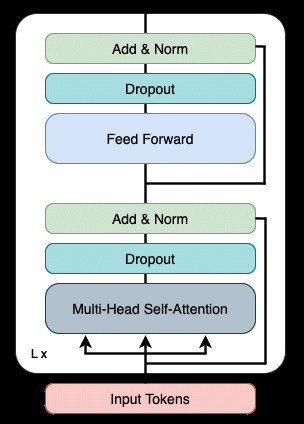

La méthode `__init__()` doit initialiser la couche d'auto-attention multi-tête, les deux couches de Normalisation (`nn.LayerNorm()`), la couche de Dropout (`nn.Dropout()`) ainsi que la couche FFN utilisant `nn.Sequential()`, `nn.Linear()` et `nn.GELU()`, dont l'équation est la suivante:

Pour un vecteur d’entrée
$x \in \mathbb{R}^{d_{\text{model}}}$ :

$$
\text{FFN}(x) = \text{GELU}(x W_1 + b_1) W_2 + b_2
$$
avec :
- $W_1 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}}$
- $b_1 \in \mathbb{R}^{d_{\text{ff}}}$
- $W_2 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}}$
- $b_2 \in \mathbb{R}^{d_{\text{model}}}$
- $d_{model}$ : dimension cachée du modèle
- $d_{ff}$ : dimension de la couche feed-forward

La méthode `forward()` doit implémenter l'équation illustrée dans la figure précédente représentant l'architecture d'un Encodeur.

In [33]:
#@title EncoderLayer
class EncoderLayer(nn.Module):
    """
    Couche d'Encodeur d'un modèle BERT.
    """

    def __init__(self, hidden_size=768, intermediate_size=3072, num_heads=12):
        """
        Args:
            hidden_size (int): Taille cachée du modèle
            intermediate_size (int): Taille de la couche FFN
            num_heads (int): Nombre de têtes d'attention
        """

        super().__init__()
        ### TODO ###
        self.attn = MultiHeadSelfAttention(hidden_size=hidden_size, num_heads=num_heads)
        self.attn_norm = nn.LayerNorm(hidden_size, eps=1e-12)

        self.ff = nn.Sequential(
            nn.Linear(hidden_size, intermediate_size),
            nn.GELU(),
            nn.Linear(intermediate_size, hidden_size)
        )
        self.ff_norm = nn.LayerNorm(hidden_size, eps=1e-12)

        self.dropout = nn.Dropout(0.1)
        ### END TODO ###

    def forward(self, x, mask=None):
        """
        Calcule le forward pass de la couche d'encodeur.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, seq_len, hidden_size)
            mask (torch.Tensor): Mask tensor of shape (batch_size, seq_len)

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, seq_len, hidden_size)
        """

        ### TODO ###
        attn_out = self.attn(x, mask)
        x = self.attn_norm(x + self.dropout(attn_out))

        ff_out = self.ff(x)
        x = self.ff_norm(x + self.dropout(ff_out))
        ### END TODO ###
        return x


**Q-3.2.4 (5 pts) Maintenant, complétez l'implémentation d'une modèle BERT traditionel en empilant les Encodeurs selon l'architecture suivante:**

La méthode `__init__()` doit initialiser :

- la **taille du vocabulaire** (`vocab_size`),
- la **dimension cachée** du modèle (`hidden_size`),
- le **nombre de couches d’encodeur** (`num_layers`),
- le **nombre de têtes d’attention** par couche (`num_heads`),
- la **taille de la couche FFN** (`intermediate_size`),
- la **taille maximale** de la séquence d’entrée (`max_position_embeddings`),
- la couche de **plongements** (`BertEmbeddings`) qui encode les identifiants de tokens, les positions et les segments,
- une **liste de couches d’encodeurs** (sous forme de `nn.ModuleList`) contenant `num_layers` instances de `EncoderLayer`, chacune représentant un bloc Transformer avec attention multi-tête et couche feedforward,
- la **fonction d’activation finale** `nn.Tanh()` appliquée au vecteur `[CLS]`.

La méthode `forward()` doit :

- appliquer la couche de plongements `BertEmbeddings` sur les `input_ids`,
- faire passer les représentations obtenues à travers chaque `EncoderLayer`, en les empilant successivement,
- retourner les sorties finales du modèle (`x`) ainsi qu’un vecteur *pooled* (calculé sur la sortie du jeton `[CLS]`, c’est-à-dire la première position). Ce vecteur *pooled* est pré-calculé pour vous et **ne sera pas utilisé dans notre tâche principale**.

In [34]:
#@title BERT model
class BertModel(nn.Module):
    """
    BERT model.
    """

    def __init__(self,
                 vocab_size,
                 hidden_size=768,
                 num_layers=12,
                 num_heads=12,
                 intermediate_size=3072,
                 max_position_embeddings=512):
        """
        Args:
            vocab_size (int): Taille du vocabulaire
            hidden_size (int): Taille cachée du modèle
            num_layers (int): Nombre de couches d'encodeur
            num_heads (int): Nombre de têtes d'attention
            intermediate_size (int): Taille de la couche FFN
            max_position_embeddings (int): Taille maximale de la séquence d'entrée
        """
        super().__init__()

        ### TODO ###
        self.embeddings = BertEmbeddings(
            vocab_size=vocab_size,
            hidden_size=hidden_size,
            max_position_embeddings=max_position_embeddings
        )

        self.layers = nn.ModuleList([
            EncoderLayer(
                hidden_size=hidden_size,
                intermediate_size=intermediate_size,
                num_heads=num_heads
            ) for _ in range(num_layers)
        ])

        self.activation = nn.Tanh()
        ### END TODO ###

        self.pooler = nn.Linear(hidden_size, hidden_size)

    def forward(self, input_ids, attention_mask=None):
        """
        Calcule le forward pass du modèle BERT.

        Args:
            input_ids (torch.Tensor): Tenseur des identifiants des tokens d'entrée
            attention_mask (torch.Tensor): Tenseur du masque d'attention
        Returns:
            torch.Tensor: Tenseur de sortie du modèle
        """

        ### TODO ###
        x = self.embeddings(input_ids)

        for layer in self.layers:
            x = layer(x, attention_mask)
        ### END TODO ###

        # pooled output: first token ([CLS])
        cls_token = x[:, 0]
        pooled = self.activation(self.pooler(cls_token))
        return x, pooled


Pour adapter un modèle BERT à la tâche de BIO tagging, nous allons construire une tête de classification FFN au dessus de la représentation finale donnée par le modèle:

$$
\hat{y}_i = \text{Softmax}(h_i W + b)
$$

avec :

- $h_i \in \mathbb{R}^{d_{\text{model}}}$ : vecteur de sortie de BERT pour le token $i$
- $ W \in \mathbb{R}^{d_{\text{model}} \times C} $, $ b \in \mathbb{R}^{C} $ : paramètres appris de la tête de classification
- $d_{\text{model}}$ : dimension cachée du modèle
- $ C $ : nombre de classes BIO
- $n$ : longueur de la séquence (nombre de tokens)  
- $ \hat{y}_i \in \mathbb{R}^{C} $ : prédiction pour le token $i$ (distribution de probabilité sur les classes)

Pour toute la séquence :

$$
\hat{Y} = \text{Softmax}(H W + b), \quad H \in \mathbb{R}^{n \times d_{\text{model}}}
$$

**Q-3.2.5 (5 pts) Finalement, complétez l'implémentation de la tête de classification ajoutée après le modèle BERT, servant à notre tâche de NER**

La méthode `__init__()` doit initialiser l'encodeur BERT (`BertModel`), la couche de classification (`nn.Linear()`), ainsi que la couche de Dropout (`nn.Dropout()`)

La méthode `forward()` doit d'abord calculer la sortie du modèle BERT en passant les input_ids ainsi que le masque d'attention, appliquer la couche de dropout puis la couche de classification. Le calcul de la perte est ensuite fourni.

In [35]:
#@title BERT for NER
class BertForNER(nn.Module):
    """
    Modèle BERT pour la tâche de NER.
    """
    def __init__(self, bert_encoder: nn.Module, hidden_size: int, num_labels: int):
        """
        Args:
            bert_encoder (nn.Module): Encodeur BERT
            hidden_size (int): Taille cachée du modèle
            num_labels (int): Nombre de labels
        """
        super().__init__()

        ### TODO ###
        self.bert = bert_encoder
        self.dropout = nn.Dropout(p=0.1)
        self.classifier = nn.Linear(hidden_size, num_labels)
        ### END TODO ###

    def forward(self, input_ids, attention_mask=None, labels=None):
        """
        Calcule le forward pass du modèle BERT pour la tâche de NER.

        Args:
            input_ids (torch.Tensor): Tenseur des identifiants des tokens d'entrée
            attention_mask (torch.Tensor): Tenseur du masque d'attention
            labels (torch.Tensor): Tenseur des étiquettes
        Returns:
            torch.Tensor: Tenseur de sortie du modèle
        """
        ### TODO ###
        sequence_output, pooled_output = self.bert(
            input_ids=input_ids, attention_mask=attention_mask
        )
        logits = self.classifier(self.dropout(sequence_output))
        ### END TODO ###

        loss = None
        if labels is not None:
            # Flatten pour CrossEntropy: ignore -100 (sous-tokens)
            loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
            loss = loss_fct(
                logits.view(-1, logits.size(-1)),
                labels.view(-1)
            )
        return {"loss": loss, "logits": logits}


In [36]:
#@title Instantiation du modèle
custom_model = BertModel(vocab_size=bert_tokenizer.vocab_size).to(device)
custom_model = BertForNER(bert_encoder=custom_model, hidden_size=768, num_labels=3).to(device)

Les deux questions suivantes pourront vous aider à valider votre implémentation

**Q-3.2.6 (3 pts) De combien de paramètres entraînables votre model custom BERT est-il composé? Montrez le détail et les étapes du calcul à la main (nombre de paramètres par couches, etc.), puis validez votre réponse en code.**

In [37]:
#@title Nombre de paramètres entrainables

### TODO ###
total_params = sum(p.numel() for p in custom_model.parameters() if p.requires_grad)
### END TODO ###

print(f"Nombre total de paramètres entraînables : {total_params}")


Nombre total de paramètres entraînables : 109483011


Réponse attendue : `109483011`

**Q-3.2.7 (2 pts) Affichez l'architecture de votre modèle (print(custom_model)) et comparez la à la sortie attendue. Si l'implémentation n'est pas identique, retournez dans les définitions de classes précédentes pour corriger les différences.**

In [38]:
#@title Affichage de l'architecture

### TODO ###
print(custom_model)
### END TODO ###


BertForNER(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768)
      (position_embeddings): Embedding(512, 768)
      (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x EncoderLayer(
        (attn): MultiHeadSelfAttention(
          (query): Linear(in_features=768, out_features=768, bias=True)
          (key): Linear(in_features=768, out_features=768, bias=True)
          (value): Linear(in_features=768, out_features=768, bias=True)
          (out): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (attn_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ff): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768

Sortie attendue:

```
BertForNER(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768)
      (position_embeddings): Embedding(512, 768)
      (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x EncoderLayer(
        (attn): MultiHeadSelfAttention(
          (query): Linear(in_features=768, out_features=768, bias=True)
          (key): Linear(in_features=768, out_features=768, bias=True)
          (value): Linear(in_features=768, out_features=768, bias=True)
          (out): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (attn_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ff): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
        (ff_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (activation): Tanh()
    (pooler): Linear(in_features=768, out_features=768, bias=True)
  )
  (classifier): Linear(in_features=768, out_features=3, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
```



### 3.3 Inférence (8 pts)

Nous allons maintenant tester l'inférence du modèle avant l'entrainement (résultat du modèle sur une entrée donnée).

Éxécutez tout d'abord la cellule suivante, définissant la fonction extract_mentions(), qui prend en entrée le texte d'une phrase, les étiquettes BIO associées, ainsi que le tokenizer, et retourne les mentions associés aux étiquettes.

L'utilisation de cette fonction est nécessaire car les jetons retournés par le tokenizer ne sont pas nécéssairement associés uns-à-uns avec les mots de la phrase, ce qui est le cas pour WordPiece, et il est donc nécessaire de faire ce post-traitement pour pouvoir lire les sorties du modèle.

In [39]:
#@title Mention Extraction Function
def extract_mentions(text, tags, tokenizer):

    # Applique le tokenizer sur le texte d'entrée
    tokens = tokenizer.tokenize(text)
    words = text.split()
    token_string_ids = tokenizer(text, return_offsets_mapping=True, return_tensors='pt')['offset_mapping'][0]

    mentions = []
    current_mention = []
    current_label = None

    # Construit les mentions au niveau des mots
    for idx, (tag, offset) in enumerate(zip(tags, token_string_ids)):
        start, end = offset.tolist()
        if start == end:
            continue  # Ignore les jetons spéciaux [CLS], etc.

        token_text = text[start:end]

        # Crée une nouvelle mention
        if tag.startswith("B-"):
            if current_mention:
                mentions.append(" ".join(current_mention))
            current_mention = [token_text]
            current_label = tag[2:]

        # Continue la mention précédente
        elif tag.startswith("I-") and current_label == tag[2:]:
            current_mention.append(token_text)
        else:
            if current_mention:
                mentions.append(" ".join(current_mention))
                current_mention = []
                current_label = None

    if current_mention:
        mentions.append(" ".join(current_mention))

    return mentions

**Q-3.3.1 (5 pts) Maitenant, complétez la fonction suivante, qui prend en entrée un modèle et son tokenizer, ainsi qu'une liste d'exemples sous forme de string (ex:`['this is a sentence', 'this is another sentence']`), et retourne en sortie les mentions annotées par le modèle, en utilisant la fonction `extract_mentions()` définie plus haut.**

Pour ce faire, le tokenizer doit être appelé sur la phrase d'entrée, puis les inputs qui seront donnés au modèle doivent être construits de la même façon que pour le DataLoader défini plus haut. Ensuite, le modèle doit être exécuté sur les entrées. Le code est ensuite fourni pour transformer la sortie en logits puis en prédictions, vous devez ensuite appeler la fonction d'extraction des mentions sur ces prédictions.

In [40]:
#@title Inference function
def inference_test(model, tokenizer, examples):

  model.eval()

  for example in examples:

    ### TODO ###
    inputs = tokenizer(
        example,
        return_tensors="pt",
        truncation=True
    )
    inputs.pop("token_type_ids", None)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
      outputs = model(**inputs)
    ### END TODO ###

    logits = outputs["logits"]

    preds = torch.argmax(logits, dim=-1)
    pred_labels = [id2label[p.item()] for p in preds[0]]

    ### TODO ###
    mentions = extract_mentions(example, pred_labels, tokenizer)
    ### END TODO ###
    print(f"Example: {example}")
    print(f"Labels Prédits: {pred_labels}")
    print(f"Mentions Prédites : {mentions}")
    print()

  return


**Q-3.3.2 (3 pts) Éxécutez la cellule suivante qui utilise la fonction définie précédement sur les dix exemples synthétiques suivants (5 qui ne font pas mention d'effets secondaires, et 5 qui le font). Faites des observations sur les sorties du modèle et expliquez ces observations.**

In [41]:
#@title Inference Test (before training)

negatives = ['The patient reports improved breathing following initiation of inhaled corticosteroids with no side effects noted.',
'Blood pressure is well controlled on current antihypertensive regimen.',
'Patient tolerated chemotherapy well with no immediate complications.',
'Continues on metformin 500 mg BID; glucose levels remain stable.',
'Patient denies any issues or concerns related to current medication use.']

positives = ['Patient developed a widespread rash suspected to be secondary to amoxicillin.',
'Complaints of dizziness began shortly after starting lisinopril.',
'Severe nausea and vomiting noted following first dose of chemotherapy.',
'Patient experienced angioedema after taking enalapril; medication discontinued.',
'Reported confusion and unsteady gait after dose increase of gabapentin.']

inf_examples = negatives + positives

inference_test(custom_model, bert_tokenizer, inf_examples)

Example: The patient reports improved breathing following initiation of inhaled corticosteroids with no side effects noted.
Labels Prédits: ['B-ADE', 'O', 'O', 'O', 'O', 'B-ADE', 'O', 'I-ADE', 'O', 'O', 'O', 'B-ADE', 'O', 'I-ADE', 'I-ADE', 'O', 'B-ADE', 'O', 'B-ADE', 'I-ADE', 'B-ADE', 'O']
Mentions Prédites : ['breathing', 'rti', 'no', 'effects noted', '.']

Example: Blood pressure is well controlled on current antihypertensive regimen.
Labels Prédits: ['B-ADE', 'O', 'I-ADE', 'B-ADE', 'O', 'I-ADE', 'O', 'I-ADE', 'O', 'O', 'O', 'O', 'I-ADE', 'I-ADE', 'B-ADE', 'O', 'O']
Mentions Prédites : ['is', 'n']

Example: Patient tolerated chemotherapy well with no immediate complications.
Labels Prédits: ['B-ADE', 'B-ADE', 'I-ADE', 'B-ADE', 'O', 'I-ADE', 'B-ADE', 'I-ADE', 'O', 'O', 'O']
Mentions Prédites : ['Patient tolerated', 'chemotherapy', 'no immediate']

Example: Continues on metformin 500 mg BID; glucose levels remain stable.
Labels Prédits: ['B-ADE', 'B-ADE', 'I-ADE', 'O', 'O', 'I-ADE', 'I

In [42]:
#@title Observations inférence
### TODO ###
"""
Avant entraînement, les prédictions sont très bruitées. Le modèle assigne
fréquemment des étiquettes ADE (B-/I-) y compris dans les phrases négatives,
et la séquence BIO est souvent incohérente (beaucoup de I- sans B-). L’extraction
retourne alors des fragments issus de WordPiece (« co », « rti », « . », etc.)
plutôt que de vraies mentions. Bref, précision et rappel sont faibles.
"""
### END TODO ###


'\nAvant entraînement, les prédictions sont très bruitées. Le modèle assigne\nfréquemment des étiquettes ADE (B-/I-) y compris dans les phrases négatives,\net la séquence BIO est souvent incohérente (beaucoup de I- sans B-). L’extraction\nretourne alors des fragments issus de WordPiece (« co », « rti », « . », etc.)\nplutôt que de vraies mentions. Bref, précision et rappel sont faibles.\n'

### 3.4 Entrainement (8 pts)

Nous sommes finalement en mesure d'entrainer notre modèle. La cellule suivante définit l'optimizer responsable des mises à jour de paramètres durant l'optimisation du modèle (ici, [AdamW](https://arxiv.org/abs/1711.05101)).

In [43]:
#@title Optimizer
NUM_EPOCHS = 10 # L'entrainement du modèle avec 10 epochs devrait durer environ 15 minutes sur GPU

custom_optimizer = AdamW(custom_model.parameters(), lr=5e-5, weight_decay=0.01)


La cellule suivante définit deux fonctions qui seront utilisées pour calculer les métriques de performance durant l'entrainement:

In [44]:
#@title Fonctions d'accumulation
def output_accumulation(all_preds, all_labels, all_masks, correct, total, inputs, outputs):
  logits = outputs["logits"]
  preds = torch.argmax(logits, dim=-1)

  mask = inputs['labels'] != -100
  correct += (preds[mask] == inputs['labels'][mask]).sum().item()
  total += mask.sum().item()

  all_preds.append(preds.detach().cpu())
  all_labels.append(inputs['labels'].detach().cpu())
  all_masks.append(inputs['attention_mask'].detach().cpu())

  return all_preds, all_labels, all_masks, correct, total

def create_metrics(all_preds, all_labels, all_masks, correct, total, total_loss, loader):
  flat_preds = torch.cat(all_preds, dim=0)
  flat_labels = torch.cat(all_labels, dim=0)
  flat_masks = torch.cat(all_masks, dim=0)

  full_inputs = {
      "labels": flat_labels,
      "attention_mask": flat_masks,
  }
  metrics = get_metrics(full_inputs, flat_preds)
  metrics['accuracy'] = correct / total
  metrics['loss'] = total_loss / len(train_loader)

  return metrics

Nous allons maintenant définir la fonction créant la boucle d'entrainement principale. Dans celle-ci, nous allons passer à travers toutes les batch du train_loader, exécuter le modèle sur ces entrées, calculer la perte et faire la rétropropagation. La cellule contient également le code fourni qui permet d'évaluer le modèle pendant l'entrainement.

Nous allons également faire un calcul similaire sur le jeu de données de validation afin de conserver une trace de la performance durant l'entrainement. La différence est qu'à ce moment nous utiliseront `torch.no_grad()` afin de ne pas mettre à jour le modèle (sans également appeler l'optimizer).

**Q-3.4.1 (5 pts) Complétez la cellule de code suivante responsable de la fonction d'entrainement et d'évaluation d'un modèle.**

Pour la partie principale de la boucle d'entrainement, suivez la section 'The Training Loop' à la page suivante : https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html.

Les seules différences sont que nous obtiendrons la perte avec `outputs['loss']` et que nous n'aurons donc pas à instancier directement les `lablels`.

In [45]:
#@title Fonction d'entrainement
def train_model(model, train_loader, val_loader, optimizer, num_epochs, full_metrics):
  for epoch in range(num_epochs):
      model.train()

      # Métriques d'entrainement
      total_loss, correct, total = 0, 0, 0
      all_preds, all_labels, all_masks = [], [], []

      # Boucle d'entrainement
      for batch in tqdm(train_loader, desc=f"Training - Epoch {epoch+1}"):

          # Voir tutoriel pytorch
          ### TODO ###
          inputs = {k: v.to(device) for k, v in batch.items()}
          model_inputs = {
              k: inputs[k] for k in ("input_ids", "attention_mask", "labels") if k in inputs
          }

          optimizer.zero_grad()
          outputs = model(**model_inputs)
          loss = outputs["loss"]
          loss.backward()
          optimizer.step()
          ### END TODO ###

          # Accumulation de la perte
          total_loss += loss.item()

          # Accumulation des sorties d'entrainement
          all_preds, all_labels, all_masks, correct, total = output_accumulation(all_preds, all_labels, all_masks, correct, total, model_inputs, outputs)

      # Métriques d'entrainement par epoch
      train_metrics = create_metrics(all_preds, all_labels, all_masks, correct, total, total_loss, train_loader)

      # -------------------------------------------------------------------
      # Calcul des métriques sur le jeu de validation

      model.eval()

      # Métriques de validation
      val_loss, correct, total = 0, 0, 0
      val_preds, val_labels, val_masks = [], [], []

      with torch.no_grad():
          for batch in tqdm(val_loader, desc=f"Validation set Eval"):

              ### TODO ###
              inputs = {k: v.to(device) for k, v in batch.items()}
              model_inputs = {
                  k: inputs[k] for k in ("input_ids", "attention_mask", "labels") if k in inputs
              }
              outputs = model(**model_inputs)
              loss = outputs["loss"]
              ### END TODO ###

              # Accumulation de la perte
              val_loss += loss.item()

              # Accumulation des sorties de validation
              val_preds, val_labels, val_masks, correct, total = output_accumulation(val_preds, val_labels, val_masks, correct, total, model_inputs, outputs)

      # Métriques de validation par epoch
      val_metrics = create_metrics(val_preds, val_labels, val_masks, correct, total, val_loss, val_loader)

      # Affichage des métriques
      print(f"Train loss: {train_metrics['loss']:.4f}")
      print(f"Val loss: {val_metrics['loss']:.4f}")
      print(f"Val token‐level accuracy: {val_metrics['accuracy']:.4f}")
      print()

      # Accumulation des métriques par epoch
      full_metrics['train'].append(train_metrics)
      full_metrics['val'].append(val_metrics)


Éxécutez maintenant la fonction sur le modèle BERT custom, avec les DataLoaders, l'optimizer et le nombre d'époques définis précédement, ainsi que le dictionnaire contenant les métriques.

In [46]:
#@title Entrainement modèle BERT custom
model = custom_model
full_metrics_custom = {'train' : [], 'val' : []}

train_model(custom_model, train_loader, val_loader, custom_optimizer, NUM_EPOCHS, full_metrics_custom)

Validation set Eval: 100%|██████████| 11/11 [00:04<00:00,  2.38it/s]


Train loss: 0.4893
Val loss: 0.0923
Val token‐level accuracy: 0.8756



Validation set Eval: 100%|██████████| 11/11 [00:04<00:00,  2.31it/s]


Train loss: 0.3565
Val loss: 0.0840
Val token‐level accuracy: 0.8826



Validation set Eval: 100%|██████████| 11/11 [00:04<00:00,  2.28it/s]


...

Train loss: 0.1704
Val loss: 0.0892
Val token‐level accuracy: 0.8844



Validation set Eval: 100%|██████████| 11/11 [00:04<00:00,  2.36it/s]


Train loss: 0.1468
Val loss: 0.0929
Val token‐level accuracy: 0.8636



Validation set Eval: 100%|██████████| 11/11 [00:04<00:00,  2.35it/s]

Train loss: 0.1331
Val loss: 0.1001
Val token‐level accuracy: 0.8871



**Q-3.4.2 (3 pts) Éxécutez finalement la cellule suivante qui ré-utilise la fonction d'inférence sur les dix mêmes exemples que précédement. Faites de nouvelles observations sur les sorties du modèle en comparant avec les sorties pré-entrainement et expliquez ces observations. Quel effet à eu l'entrainement sur le modèle?**

In [47]:
#@title Inference Test (After training)

inference_test(custom_model, bert_tokenizer, inf_examples)

Example: The patient reports improved breathing following initiation of inhaled corticosteroids with no side effects noted.
Labels Prédits: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ADE', 'O', 'O', 'B-ADE', 'O', 'I-ADE', 'O', 'O', 'O', 'I-ADE', 'O', 'O', 'O']
Mentions Prédites : ['inhaled', 'cos']

Example: Blood pressure is well controlled on current antihypertensive regimen.
Labels Prédits: ['O', 'B-ADE', 'I-ADE', 'I-ADE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Mentions Prédites : ['Blood pressure is']

Example: Patient tolerated chemotherapy well with no immediate complications.
Labels Prédits: ['O', 'O', 'I-ADE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Mentions Prédites : []

Example: Continues on metformin 500 mg BID; glucose levels remain stable.
Labels Prédits: ['O', 'B-ADE', 'I-ADE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Mentions Prédites : ['Continues on']

Example: Patient denies any issues or concerns related to cur

In [48]:
#@title Observations inférence
### TODO ###
"""
Après entraînement, le bruit diminue nettement : on voit davantage de « O » sur
les phrases négatives (malgré quelques faux positifs comme « denies any issues »),
et des détections partielles sur les positifs (p. ex. « Severe nausea », « confusion »).
D’autres mentions restent manquées ou tronquées (« dizziness », « angioedema » → « en »).
Cela reflète les métriques de validation (acc ≈ 0,889) : progrès clair, mais encore
des ratés sur la cohérence BIO et la complétude des spans.
"""
### END TODO ###

'\nAprès entraînement, le bruit diminue nettement : on voit davantage de « O » sur\nles phrases négatives (malgré quelques faux positifs comme « denies any issues »),\net des détections partielles sur les positifs (p. ex. « Severe nausea », « confusion »).\nD’autres mentions restent manquées ou tronquées (« dizziness », « angioedema » → « en »).\nCela reflète les métriques de validation (acc ≈ 0,889) : progrès clair, mais encore\ndes ratés sur la cohérence BIO et la complétude des spans.\n'

---
## 4. Alternative pré-entrainée (10 pts)

Nous allons maintenant tester la version pré-entrainée de BERT sur la même tâche de NER. Nous pourrons ainsi comparer les performances de cette alternative à celles de notre modèle custom.

### 4.1 BERT-base (10 pts)

Tout d'abord, nous allons télécharger le tokenizer et le modèle BERT, en utilisant `BertForTokenClassification` afin d'y ajouter une tête de classification nous permettant de faire l'étiquettage BIO.

In [49]:
#@title Téléchargement BERT-base

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)
bert_model = BertForTokenClassification.from_pretrained("bert-base-uncased", num_labels=len(label2id))
bert_model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

**Q-4.1.1 (3 pts) Éxécutez la cellule suivante qui utilise la fonction d'inférence à nouveau sur les mêmes exemples. Faites des observations sur les sorties du modèle et expliquez ces observations, en comparaison avec les deux autres tests d'inférence faits précédement.**

In [50]:
#@title Test d'inférence BERT-base

inference_test(bert_model, bert_tokenizer, inf_examples)

Example: The patient reports improved breathing following initiation of inhaled corticosteroids with no side effects noted.
Labels Prédits: ['I-ADE', 'B-ADE', 'B-ADE', 'B-ADE', 'B-ADE', 'O', 'O', 'O', 'I-ADE', 'O', 'I-ADE', 'O', 'O', 'B-ADE', 'O', 'I-ADE', 'B-ADE', 'O', 'O', 'B-ADE', 'O', 'O']
Mentions Prédites : ['The', 'patient', 'reports', 'improved', 'ter', 'no', 'noted']

Example: Blood pressure is well controlled on current antihypertensive regimen.
Labels Prédits: ['I-ADE', 'I-ADE', 'O', 'B-ADE', 'B-ADE', 'B-ADE', 'I-ADE', 'B-ADE', 'B-ADE', 'O', 'B-ADE', 'B-ADE', 'O', 'O', 'B-ADE', 'O', 'O']
Mentions Prédites : ['is', 'well', 'controlled on', 'current', 'anti', 'per', 'tens', 'n']

Example: Patient tolerated chemotherapy well with no immediate complications.
Labels Prédits: ['I-ADE', 'I-ADE', 'B-ADE', 'B-ADE', 'B-ADE', 'B-ADE', 'B-ADE', 'B-ADE', 'B-ADE', 'B-ADE', 'O']
Mentions Prédites : ['tolerated', 'chemotherapy', 'well', 'with', 'no', 'immediate', 'complications', '.']

Exam

In [51]:
#@title Observations inférence
### TODO ###
"""
Sans affinage, BERT-base applique massivement I-ADE et ne respecte pas bien le
schéma BIO. Conséquence : l’extraction renvoie peu ou pas de mentions (souvent
un simple « . » quand un B-ADE tombe sur la ponctuation). Le modèle n’est pas
encore adapté au domaine/jeu d’étiquettes et mélange faux positifs et séquences
illisibles.
"""
### END TODO ###

'\nSans affinage, BERT-base applique massivement I-ADE et ne respecte pas bien le\nschéma BIO. Conséquence : l’extraction renvoie peu ou pas de mentions (souvent\nun simple « . » quand un B-ADE tombe sur la ponctuation). Le modèle n’est pas\nencore adapté au domaine/jeu d’étiquettes et mélange faux positifs et séquences\nillisibles.\n'

Les cellules suivantes instancient de nouveau des DataLoaders utilisant le tokenizer de BERT et créent un nouvel optimizer.

In [52]:
#@title Datasets
train_dataset = NERDataset(train_examples, bert_tokenizer, label2id)
test_dataset  = NERDataset(test_examples, bert_tokenizer, label2id)
val_dataset   = NERDataset(val_examples, bert_tokenizer, label2id)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=False,
                          collate_fn=lambda batch: {
                              'input_ids': torch.stack([item['input_ids'] for item in batch]),
                              'attention_mask': torch.stack([item['attention_mask'] for item in batch]),
                              'labels': torch.stack([item['labels'] for item in batch]),
                          })

val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=False,
                        collate_fn=train_loader.collate_fn)

test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False,
                         collate_fn=train_loader.collate_fn)

In [53]:
#@title Optimizer

NUM_EPOCHS = 10
bert_optimizer = AdamW(bert_model.parameters(), lr=5e-5, weight_decay=0.01)

**Q-4.1.2 (4 pts) Nous allons maintenant réutiliser la fonction d'entrainement définie à la question 3.3.1. Éxécutez la cellule suivante pour faire l'affinage du modèle BERT-base.**

In [54]:
#@title Affinage BERT-base
model = bert_model
full_metrics_bert = {'train' : [], 'val' : []}

train_model(bert_model, train_loader, val_loader, bert_optimizer, NUM_EPOCHS, full_metrics_bert)

Validation set Eval: 100%|██████████| 11/11 [00:04<00:00,  2.54it/s]


Train loss: 0.2736
Val loss: 0.0275
Val token‐level accuracy: 0.9518



Validation set Eval: 100%|██████████| 11/11 [00:04<00:00,  2.43it/s]


Train loss: 0.0940
Val loss: 0.0245
Val token‐level accuracy: 0.9620



Validation set Eval: 100%|██████████| 11/11 [00:04<00:00,  2.48it/s]


...

Train loss: 0.0080
Val loss: 0.0370
Val token‐level accuracy: 0.9650



Validation set Eval: 100%|██████████| 11/11 [00:04<00:00,  2.48it/s]


Train loss: 0.0068
Val loss: 0.0397
Val token‐level accuracy: 0.9630



Validation set Eval: 100%|██████████| 11/11 [00:04<00:00,  2.49it/s]

Train loss: 0.0056
Val loss: 0.0398
Val token‐level accuracy: 0.9655



**Q-4.1.3 (3 pts) Éxécutez à nouveau le test d'inférence. Faites de nouvelles observations sur les sorties du modèle et expliquez ces observations, en comparant avec le premier test d'inférence fait sur BERT-base avant affinage.**

In [55]:
#@title BERT Inference test (after training)

inference_test(bert_model, bert_tokenizer, inf_examples)

Example: The patient reports improved breathing following initiation of inhaled corticosteroids with no side effects noted.
Labels Prédits: ['O', 'O', 'O', 'O', 'B-ADE', 'I-ADE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Mentions Prédites : ['improved breathing']

Example: Blood pressure is well controlled on current antihypertensive regimen.
Labels Prédits: ['O', 'B-ADE', 'I-ADE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Mentions Prédites : ['Blood pressure']

Example: Patient tolerated chemotherapy well with no immediate complications.
Labels Prédits: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Mentions Prédites : []

Example: Continues on metformin 500 mg BID; glucose levels remain stable.
Labels Prédits: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Mentions Prédites : []

Example: Patient denies any issues or concerns related to current medication use.
Labels Prédits: 

In [56]:
#@title Observations inférence
### TODO ###
"""
Après affinage, la performance monte nettement (acc. val ≈ 0,965 ; perte ≈ 0,036).
En pratique, les phrases positives montrent des mentions continues démarrant en
B-ADE, et les négatives restent vides ou quasi vides. Par rapport au modèle
custom, la convergence est plus rapide et les spans sont en général plus propres,
ce qui correspond à l’écart d’accuracy observé.
"""
### END TODO ###


'\nAprès affinage, la performance monte nettement (acc. val ≈ 0,965 ; perte ≈ 0,036).\nEn pratique, les phrases positives montrent des mentions continues démarrant en\nB-ADE, et les négatives restent vides ou quasi vides. Par rapport au modèle\ncustom, la convergence est plus rapide et les spans sont en général plus propres,\nce qui correspond à l’écart d’accuracy observé.\n'

---
## 5. Évaluation (8 pts)

Maintenant que nous avons entrainé nos deux modèles (BERT custom et BERT-base), nous allons comparer les métriques de performances recueillies durant l'entrainement.

### 5.1 Fonctions de visualisation

La cellule suivante définit les différentes fonctions utilisées pour la visualisation des métriques de performance.

In [58]:
#@title Fonctions de visualisation

def get_color_pairs(colormap, num_colors, lighten_factor=0.5):
    """
    Génère une liste de couleurs selon une palette, avec une
     version pleine et une version plus pale de la même couleur

    Args:
        colormap: Un object colormap de matplotlib
        num_colors: Nombre de couleurs à générer
        lighten_factor: Factuer de réduction de luminosité de la couleur

    Returns:
        List of colors: [color0, light_color0, color1, light_color1, ...]
    """
    base_colors = [colormap(i) for i in range(num_colors)]
    hex_base = [mcolors.to_hex(c) for c in base_colors]
    color_pairs = []
    white = (1.0, 1.0, 1.0)

    for c in hex_base:
        color_pairs.append(c)
        c = mcolors.to_rgb(c)
        color_pairs.append(mcolors.to_hex([c[i] + (white[i] - c[i]) * lighten_factor for i in range(3)]))

    return color_pairs


def plot_mention_metrics(
    *metric_pairs,
    names,
    show_train=True,
    show_val=True,
    show_exact=True,
    show_overlap=True,
):
    """
    Affiche les métriques d'une ou plusieurs paires (train_metrics, val_metrics)

    Args:
        *metric_pairs: Tuples de (train_metrics, val_metrics)
        show_train (bool): Affichage ou non des métriques d'entrainement
        show_val (bool): Affichage ou non des métriques de validation
        show_exact (bool): Affichage ou non des métriques de F1 exactes
        show_overlap (bool): Affichage ou non des métriques de F1 approximatives
        labels (list[str]): Liste de labels pour les différentes séries de métriques
    """

    # Génération du colormap
    c = cm.get_cmap('tab10', 10)
    colors = get_color_pairs(c, len(metric_pairs), lighten_factor=0.3)

    plt.figure(figsize=(18, 5))

    c = 0

    for i, (train_metrics, val_metrics) in enumerate(metric_pairs):
        epochs = list(range(1, len(train_metrics) + 1))

        # Perte
        train_loss = [m['loss'] for m in train_metrics]
        val_loss = [m['loss'] for m in val_metrics]

        # Accuracy
        train_acc = [m['accuracy'] for m in train_metrics]
        val_acc = [m['accuracy'] for m in val_metrics]

        # F1 Exact
        if show_exact:
            train_exact_f1 = [m['exact']['f1'] for m in train_metrics]
            val_exact_f1 = [m['exact']['f1'] for m in val_metrics]

        # F1 Approximatif
        if show_overlap:
            train_overlap_f1 = [m['overlap']['f1'] for m in train_metrics]
            val_overlap_f1 = [m['overlap']['f1'] for m in val_metrics]

        label_prefix = names[i]

        # Plot Loss
        plt.subplot(1, 3, 1)
        if show_train:
            plt.plot(epochs, train_loss, label=f'{label_prefix} Train', marker='o', color=colors[c])
        if show_val:
            plt.plot(epochs, val_loss, label=f'{label_prefix} Val', marker='x', color=colors[c+1])
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss over Epochs')
        plt.legend()

        # Plot Accuracy
        plt.subplot(1, 3, 2)
        if show_train:
            plt.plot(epochs, train_acc, label=f'{label_prefix} Train', marker='o', color=colors[c])
        if show_val:
            plt.plot(epochs, val_acc, label=f'{label_prefix} Val', marker='x', color=colors[c+1])
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Accuracy over Epochs')
        plt.legend()

        # Plot F1 Scores
        plt.subplot(1, 3, 3)
        if show_exact:
            if show_train:
                plt.plot(epochs, train_exact_f1, label=f'{label_prefix} Train Exact F1', marker='o', color=colors[c])
            if show_val:
                plt.plot(epochs, val_exact_f1, label=f'{label_prefix} Val Exact F1', marker='x', color=colors[c+1])
        if show_overlap:
            if show_train:
                plt.plot(epochs, train_overlap_f1, label=f'{label_prefix} Train Overlap F1', marker='o', linestyle='--', color=colors[c])
            if show_val:
                plt.plot(epochs, val_overlap_f1, label=f'{label_prefix} Val Overlap F1', marker='x', linestyle='--', color=colors[c+1])
        plt.xlabel('Epoch')
        plt.ylabel('F1 Score')
        plt.title('F1 Score over Epochs')
        plt.legend()

        c += 2

    plt.tight_layout()
    plt.show()

def plot_label_metrics(models, names):
    """
    Affiche le score F1 par étiquette ('O', 'B-ADE', 'I-ADE') par epoch pour chaque modèle

    Args:
        models (list): Liste ou chaque élément est un dictionnaire avec les clés 'train' et 'val'
                        chacun contenant une liste de dictionnaires par époch avec les métriques 'label'
        names (list): Liste de noms pour les différentes séries de métriques
    """
    labels = ['O', 'B-ADE', 'I-ADE']
    markers = {'O': '$O$', 'B-ADE': '$B$', 'I-ADE': '$I$'}
    colors = cm.get_cmap('tab10', 10)

    plt.figure(figsize=(10, 6))

    for i, model in enumerate(models):
        color = colors(i)
        epochs = list(range(1, len(model['val']) + 1))

        for label in labels:
            f1_scores = []
            for epoch_metrics in model['val']:
                f1 = epoch_metrics['label'][label]['f1'] if label in epoch_metrics['label'] else None
                f1_scores.append(f1)
            plt.plot(
                epochs,
                f1_scores,
                label=f'{names[i]} - {label}',
                marker=markers[label],
                color=color,
                linestyle='-'
            )

    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.title('Label-wise F1 Score over Epochs (Validation set)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### 5.2 Visualisations (8 pts)

**Q-5.2.1 (4 pts) La cellule suivante fait l'affichage des visualisations de l'évolution de la performance au niveau des mentions par époque (epoch). Comparez la performance des trois modèles durant l'entrainement, par rapport à:**
- **La perte**
- **L'accuracy par étiquette (Pourcentage d'étiquettes correctement identifiées)**
- **Le score F1 (Exact)**

**Faites des observations par rapport à chaque point et motivez ces observations. Portez également attention à la distinction entre les performances sur le jeu d'entrainement et le jeu de validation. Commentez également la présence ou non de sur-apprentissage.**

/tmp/ipython-input-1668729634.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c = cm.get_cmap('tab10', 10)


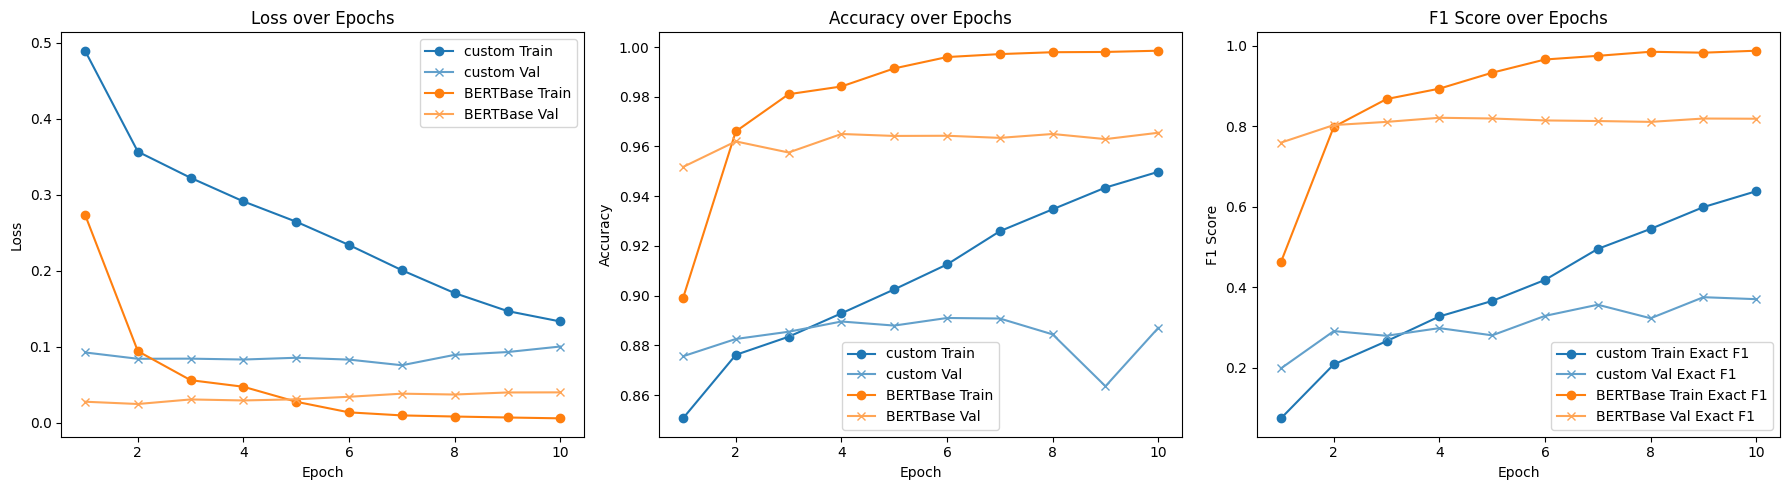

In [59]:
#@title Évaluation au niveau des mentions
plot_mention_metrics((full_metrics_custom['train'], full_metrics_custom['val']),
                     (full_metrics_bert['train'], full_metrics_bert['val']),
             names=['custom', 'BERTBase'],
             show_overlap=False)

In [63]:
#@title Réponse évaluation mentions
### TODO ###
"""
Tout d'abord, si on s'intéresse à la perte, les 2 modèles ont une bonne capacité d'apprentissage sur le jeu d'entraînement car la perte (sur le jeu d'entraînement décroit quasiment de façon linéaire (mise à part sur la première époque ce qui est normal car le modèle ajuste plus rapidement ces poids généralement au début). BERTBase obtient de meilleurs résultatsavec une décroissance qui tend vers 0
On niveau de la validation BERTBase a à nouveau de meilleurs résultats avec une perte très faible. Cependant, pour les 2 modèles, on remarque que la perte sur le jeu de validation est quasi constante mais a tout de même tendance à augmenter d'époque en époque. Ainsi, d'une part le modèle continue d'apprendre et de s'adapter aux données d'entraînement car la perte train diminue mais sa capacité de généralisation sur des données nouvelles se dégrade légérement. Il y a ainsi du sur apprentissage.
On pourrait donc arrêter le modèle plus tôt (7 époques par exemple pour le modèle custom) et tout de même obtenir de meilleurs résultats.

Au niveau de l'accuracy par étiquette, on remarque que sur l'entraînement, BERTBase atteint assez rapidement une précision presque parfaite cohérente avec la perte quasi nulle et avec le fait qu'il soit pré-entrainé.
Pour le modèle custom, on a une croissance progressive qui prouve que le modèle apprend bien de mieux en mieux à bien représenter les étiquettes.
Sur le jeu de validation, le modèle BASE est très haut et stable : il s'aligne aux données vue pendant le train mais n'apprend plus rien après certaines époques (risque de sur apprentissage).
Le modèle custom aussi généralise moins bien, il stagne avec même une baisse en fin d'entraînement. Lui aussi apprend à mieux coller au jeu d'entraîenement.
BERTBase reste plus performant (malgré les risques de sur-apprentissage) et cela confirme les résultats obtenus précédemment ou notre modèle custom était plus bruité avec pas mal de faux positifs.

Enfin, pour le score F1, on obtient des résultats similaires avec une croissance jusqu'à 1 du modèle Base sur nos données d'entraînements et atteint un F1 stable autour de 0.8 sur le jeu de validation dès les premières époques.
Le custom progresse lentement mais plafonne autour de 0,4 en validation, ce qui confirme nos résultats précédents où le custom identifie parfois seulement une partie des entités (« en » pour « angioedema » ), alors que BERT-base repère mieux les mentions.

Plus généralement, le modèle Base obtient de bien meilleurs résultats.


"""
### END TODO ###

"\nTout d'abord, si on s'intéresse à la perte, les 2 modèles ont une bonne capacité d'apprentissage sur le jeu d'entraînement car la perte (sur le jeu d'entraînement décroit quasiment de façon linéaire (mise à part sur la première époque ce qui est normal car le modèle ajuste plus rapidement ces poids généralement au début). BERTBase obtient de meilleurs résultatsavec une décroissance qui tend vers 0\nOn niveau de la validation BERTBase a à nouveau de meilleurs résultats avec une perte très faible. Cependant, pour les 2 modèles, on remarque que la perte sur le jeu de validation est quasi constante mais a tout de même tendance à augmenter d'époque en époque. Ainsi, d'une part le modèle continue d'apprendre et de s'adapter aux données d'entraînement car la perte train diminue mais sa capacité de généralisation sur des données nouvelles se dégrade légérement. Il y a ainsi du sur apprentissage.\nOn pourrait donc arrêter le modèle plus tôt (7 époques par exemple pour le modèle custom) et to

**Q-5.2.2 (4 pts) La cellule suivante fait l'affichage des visualisations de l'évolution de la performance au niveau des étiquettes par époque. Comparez la performance des trois modèles durant l'entrainement, par rapport à:**
- **La différence de performance entre les différentes étiquettes**
- **La différence de performance entre les différents modèles**
- **Le niveau de performance atteint**

**Faites des observations par rapport à chaque point et motivez ces observations. Ces courbes montrent la performance sur le jeu de validation.**

/tmp/ipython-input-1668729634.py:135: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', 10)


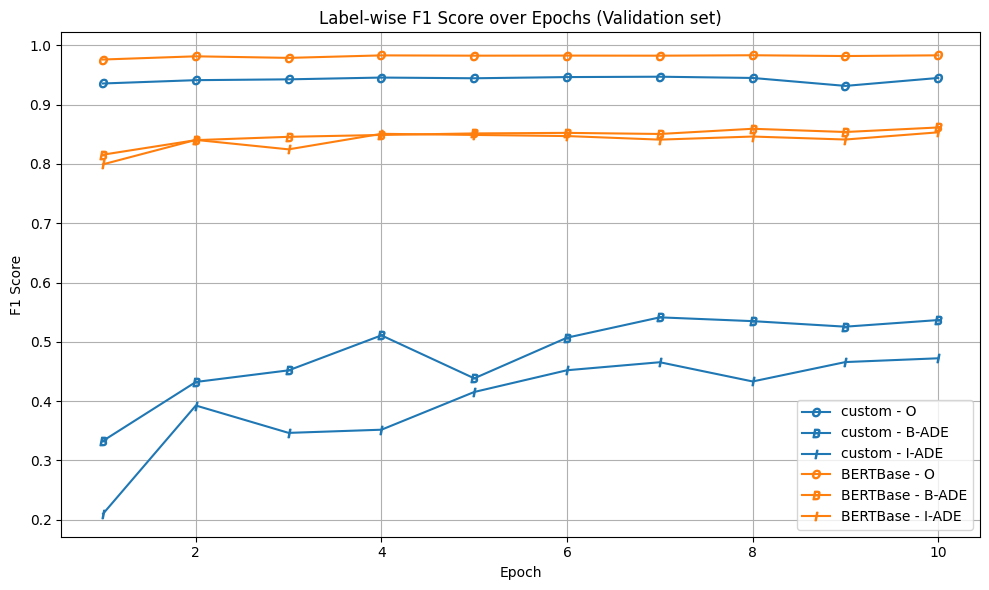

In [64]:
#@title Évaluation au niveau des étiquettes
plot_label_metrics([full_metrics_custom, full_metrics_bert], ['custom', 'BERTBase'])

In [65]:
#@title Réponse évaluation étiquettes
### TODO ###
"""
Tout d'abord, au niveau des étiquettes, on remarque que l'étiquette O est celle qui obtient les meilleurs résultats car c'est l'étiquette qui est largement majoritaire dans les données : prédire O par défaut est souvent correct (cela peut donc introduire un biais si on regarde les performances sur cette étiquette pour évaluer la performance générale).
Ensuite, pour les 2 modèles, les performances sur l'étiquette I sont légèrement inférieures (mais reste similaires) à celles sur B. Une première explication peut être que si le modèle se trompe sur le début d'une entité, alors il va se tromper sur le token interne. De plus, les I sont forcément moins fréquents que les B (car I implique B avant mais B n'implique pas forcément I après).

Pour la comparaison globale entre nos 2 modèles, on confirme nos résultats précédents avec des bien meilleures performances sur la détéction de B et I (car la détéction de O ne reflète pas vraiment la performance du modèle). Le modèle custom arrive à reconnaître les tokens qui ne sont pas des O mais a du mal à identifier correctement s'il s'agit de I ou de B.

Enfin, on confirme cette idée de meilleure performance pour notre modèle pré-entrainé par le niveau de performance atteint. BERTBase a des résultats hauts et stables (O: presque 1, B: 0.85, I: 0.85). Notre modèle custom a des bons résultats pour les tokens O qui sont majoritaires mais des performances qui sont quasiement 2 fois moins bonnes que notre BERTBase pour les B et les I (O: 0.95, B: 0.55, I: 0.5).

Les courbes confirment que BERTBase généralise mieux sur toutes les étiquettes, en particulier les plus rares).
"""
### END TODO ###

"\nTout d'abord, au niveau des étiquettes, on remarque que l'étiquette O est celle qui obtient les meilleurs résultats car c'est l'étiquette qui est largement majoritaire dans les données : prédire O par défaut est souvent correct (cela peut donc introduire un biais si on regarde les performances sur cette étiquette pour évaluer la performance générale).\nEnsuite, pour les 2 modèles, les performances sur l'étiquette I sont légèrement inférieures (mais reste similaires) à celles sur B. Une première explication peut être que si le modèle se trompe sur le début d'une entité, alors il va se tromper sur le token interne. De plus, les I sont forcément moins fréquents que les B (car I implique B avant mais B n'implique pas forcément I après). \n\nPour la comparaison globale entre nos 2 modèles, on confirme nos résultats précédents avec des bien meilleures performances sur la détéction de B et I (car la détéction de O ne reflète pas vraiment la performance du modèle). Le modèle custom arrive à

---
## 6. Question d'analyse (7 pts)

### 6.1 Différences de performance (4 pts)

**Q-6.1.1 (4 pts) Comment expliquez vous la différence de performance entre le modèle BERT custom et le modèle BERT-base?**

In [ ]:
#@title Réponse 6.1.1
"""

"""

### 6.2 Améliorations potentielles (3 pts)

**Q-6.2.1 (3 pts) Proposez des pistes des solutions ou des idées ayant le potentiel d'améliorer les performances sur la tâche par rapport au meilleur modèle testé.**

In [ ]:
#@title Réponse 6.2.1
"""

"""

## Livrables
Vous devez remettre votre notebook sur Moodle en ipynb et pdf sous forme de inf8460_TP2_grX_equipeY.zip (renommez X et Y selon votre groupe de laboratoire et votre numéro d'équipe) et sur Gradescope en pdf. Pour Gradescope vous devez associer les numéros de questions avec vos réponses dans le pdf grâce à l'outil que fournit Gradescope. Assurez-vous que votre PDF représente bien votre notebook sans problème de formatage. Un notebook mal généré en PDF ne sera pas évalué.


## Évaluation
Votre TP sera évalué selon les critères suivants :
1. Exécution correcte du code et obtention des sorties attendues
2. Réponses correctes aux questions d'analyse
3. Qualité du code (noms significatifs, structure, performance, gestion d’exception, etc.)
4. Commentaires clairs et informatifs